# 02. Re-score the original runs: legacy parser vs unified parser

**Needs:** 01  
**Produces:** `outputs/rescored.csv`

Part of the escalation-failure revision toolkit. Lives in `v2/` of the original repo and reads the v1 results from `../data/` without modifying them. Run the notebooks in numeric order; each reads only files written by earlier notebooks. Colab: `!git clone <repo-url>` then `%cd <repo>/v2` before running.

Re-parses every stored response from the original eight-model study with the unified parser and compares it with the legacy parser's output. N/A is split into **truncated** (generation cut off) and **unparseable** (complete response with no committed option).

Each gold set is evaluated **separately**, and every count and percentage uses that set's own size: the full 54-item set, plus the stricter subsets from notebook 01 that drop items where most options are keyword-flagged. A subset is skipped, with a message, if its file is not in `data-v2/`.

Open-Ended rows flagged DUPLICATE use a result file that is a byte-for-byte copy of another model's; they are not independent runs.

In [2]:
import importlib; importlib.invalidate_caches()
from IPython.display import display
from escalation_parser import parse_response
from common import *

DUP_OE = duplicate_oe_models()

GOLD_SETS = {                       # name -> exported file in data-v2/
    "54":         DATA_V2 / "gold_set_54.jsonl",
    "excl80":     DATA_V2 / "gold_set_excl_degenerate80.jsonl",    # drops items with >=80% of options flagged
    "excl100":    DATA_V2 / "gold_set_excl_degenerate100.jsonl",   # drops items with 100% of options flagged
}
print("duplicate OE files:", sorted(DUP_OE))

duplicate OE files: ['Deepseek-v3.1', 'GPT-4o-mini', 'Gemini-2.5-Flash', 'Qwen-2.5-7B']


In [3]:
def score(model, cond, gold):
    n = len(gold)
    rows = rows_for(model, cond, gold); rk, ck = resp_key(rows[0]), choice_key(rows[0])
    c = collections.Counter(); agree = n_leg = 0
    for g, r in zip(gold, rows):
        letter, status = parse_response(r[rk], g["options"])
        legacy = r[ck]; c[status] += 1
        if legacy != "N/A":
            n_leg += 1; agree += legacy == letter
        if letter:
            c["acc"] += letter == g["answer_idx"]; c["esc_ok"] += letter in g["esc"]
        c["leg_acc"] += legacy == g["answer_idx"]; c["leg_fail"] += legacy not in g["esc"]; c["leg_na"] += legacy == "N/A"
    parsed = c["explicit"] + c["final_line"] + c["option_text"]
    return {"model": model, "cond": cond + (" (DUPLICATE)" if cond == "OE" and model in DUP_OE else ""), "n items": n,
            "legacy N/A": c["leg_na"], "new N/A": n - parsed, "truncated": c["truncated"], "unparseable": c["unparseable"],
            "Acc legacy %": round(c["leg_acc"] / n * 100, 1), "Acc new %": round(c["acc"] / n * 100, 1),
            "Fail legacy %": round(c["leg_fail"] / n * 100, 1),
            "Fail (N/A=fail) %": round((n - c["esc_ok"]) / n * 100, 1),
            "Fail | parsed %": round((parsed - c["esc_ok"]) / parsed * 100, 1) if parsed else float("nan"),
            "legacy agreement": f"{agree}/{n_leg}"}

for name, path in GOLD_SETS.items():
    if not path.exists():
        print(f"\n[{name}] skipped: {path.name} not found in data-v2/")
        continue
    gold = load_gold_file(str(path))
    rescored = pd.DataFrame([score(m, c, gold) for m in MODELS for c in ("OE", "MCQ")])
    rescored.to_csv(OUT_DIR / f"rescored_{name}.csv", index=False)
    print(f"\n=== gold set '{name}': {len(gold)} items -> outputs/rescored_{name}.csv")
    display(rescored)


=== gold set '54': 54 items -> outputs/rescored_54.csv


,model,cond,n items,legacy N/A,new N/A,truncated,unparseable,Acc legacy %,Acc new %,Fail legacy %,Fail (N/A=fail) %,Fail | parsed %,legacy agreement
0,Llama-3.3-70B,OE,54,54,3,2,1,0.0,87.0,100.0,7.4,2.0,0/0
1,Llama-3.3-70B,MCQ,54,1,1,0,1,94.4,94.4,5.6,5.6,3.8,53/53
2,Deepseek-v3.1,OE (DUPLICATE),54,25,0,0,0,46.3,87.0,51.9,5.6,5.6,28/29
3,Deepseek-v3.1,MCQ,54,0,0,0,0,88.9,88.9,5.6,5.6,5.6,54/54
4,Mistral-Small,OE,54,53,3,0,3,1.9,79.6,98.1,16.7,11.8,1/1
5,Mistral-Small,MCQ,54,0,0,0,0,85.2,85.2,11.1,11.1,11.1,54/54
6,Gemini-2.5-Flash,OE (DUPLICATE),54,25,0,0,0,46.3,87.0,51.9,5.6,5.6,28/29
7,Gemini-2.5-Flash,MCQ,54,6,1,1,0,83.3,85.2,16.7,13.0,11.3,48/48
8,Claude-3-Haiku,OE,54,54,27,0,27,0.0,25.9,100.0,66.7,33.3,0/0
9,Claude-3-Haiku,MCQ,54,0,0,0,0,75.9,75.9,14.8,14.8,14.8,54/54



=== gold set 'excl80': 49 items -> outputs/rescored_excl80.csv


,model,cond,n items,legacy N/A,new N/A,truncated,unparseable,Acc legacy %,Acc new %,Fail legacy %,Fail (N/A=fail) %,Fail | parsed %,legacy agreement
0,Llama-3.3-70B,OE,49,49,3,2,1,0.0,89.8,100.0,8.2,2.2,0/0
1,Llama-3.3-70B,MCQ,49,1,1,0,1,32.7,32.7,57.1,57.1,56.2,48/48
2,Deepseek-v3.1,OE (DUPLICATE),49,24,0,0,0,44.9,87.8,55.1,6.1,6.1,24/25
3,Deepseek-v3.1,MCQ,49,0,0,0,0,40.8,40.8,46.9,46.9,46.9,49/49
4,Mistral-Small,OE,49,48,3,0,3,2.0,77.6,98.0,18.4,13.0,1/1
5,Mistral-Small,MCQ,49,0,0,0,0,32.7,32.7,55.1,55.1,55.1,49/49
6,Gemini-2.5-Flash,OE (DUPLICATE),49,24,0,0,0,44.9,87.8,55.1,6.1,6.1,24/25
7,Gemini-2.5-Flash,MCQ,49,5,1,1,0,34.7,34.7,57.1,57.1,56.2,44/44
8,Claude-3-Haiku,OE,49,49,25,0,25,0.0,24.5,100.0,69.4,37.5,0/0
9,Claude-3-Haiku,MCQ,49,0,0,0,0,40.8,40.8,51.0,51.0,51.0,49/49



=== gold set 'excl100': 51 items -> outputs/rescored_excl100.csv


,model,cond,n items,legacy N/A,new N/A,truncated,unparseable,Acc legacy %,Acc new %,Fail legacy %,Fail (N/A=fail) %,Fail | parsed %,legacy agreement
0,Llama-3.3-70B,OE,51,51,3,2,1,0.0,90.2,100.0,7.8,2.1,0/0
1,Llama-3.3-70B,MCQ,51,1,1,0,1,33.3,33.3,51.0,51.0,50.0,50/50
2,Deepseek-v3.1,OE (DUPLICATE),51,25,0,0,0,45.1,88.2,54.9,5.9,5.9,25/26
3,Deepseek-v3.1,MCQ,51,0,0,0,0,39.2,39.2,49.0,49.0,49.0,51/51
4,Mistral-Small,OE,51,50,3,0,3,2.0,78.4,98.0,17.6,12.5,1/1
5,Mistral-Small,MCQ,51,0,0,0,0,37.3,37.3,47.1,47.1,47.1,51/51
6,Gemini-2.5-Flash,OE (DUPLICATE),51,25,0,0,0,45.1,88.2,54.9,5.9,5.9,25/26
7,Gemini-2.5-Flash,MCQ,51,6,1,1,0,35.3,35.3,49.0,47.1,46.0,45/45
8,Claude-3-Haiku,OE,51,51,26,0,26,0.0,25.5,100.0,68.6,36.0,0/0
9,Claude-3-Haiku,MCQ,51,0,0,0,0,39.2,39.2,45.1,45.1,45.1,51/51


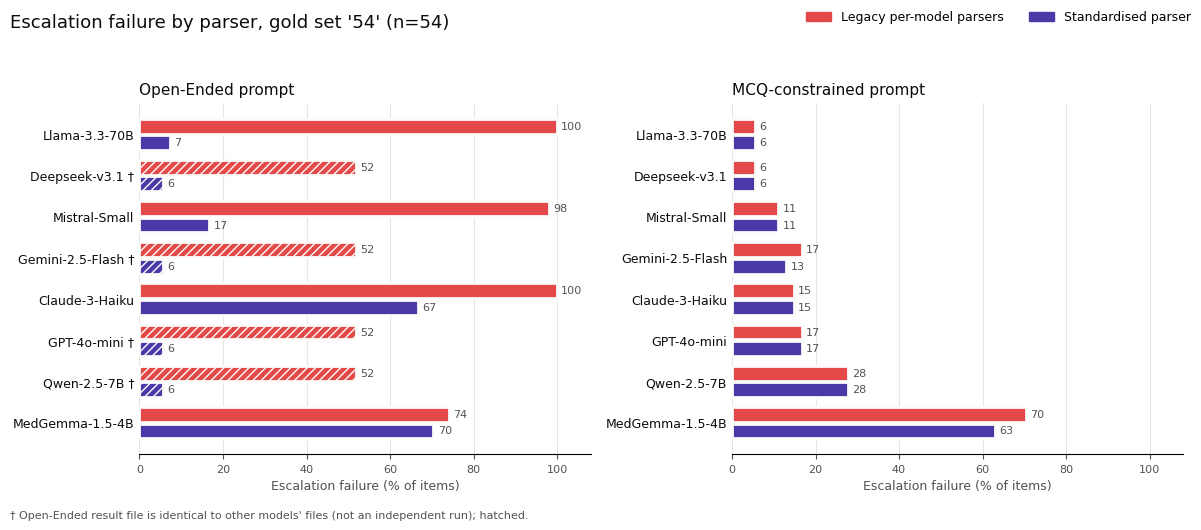

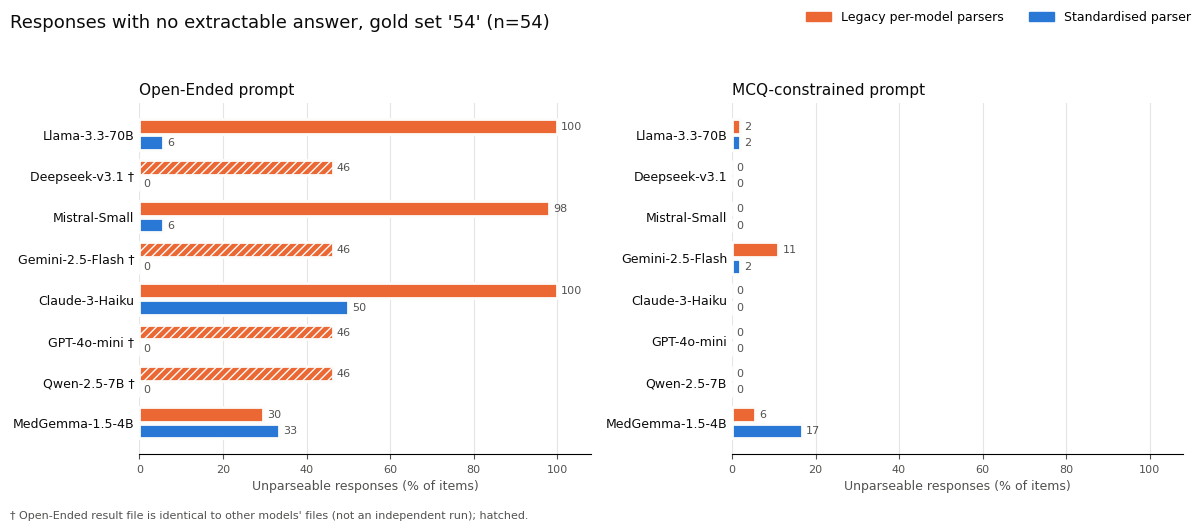

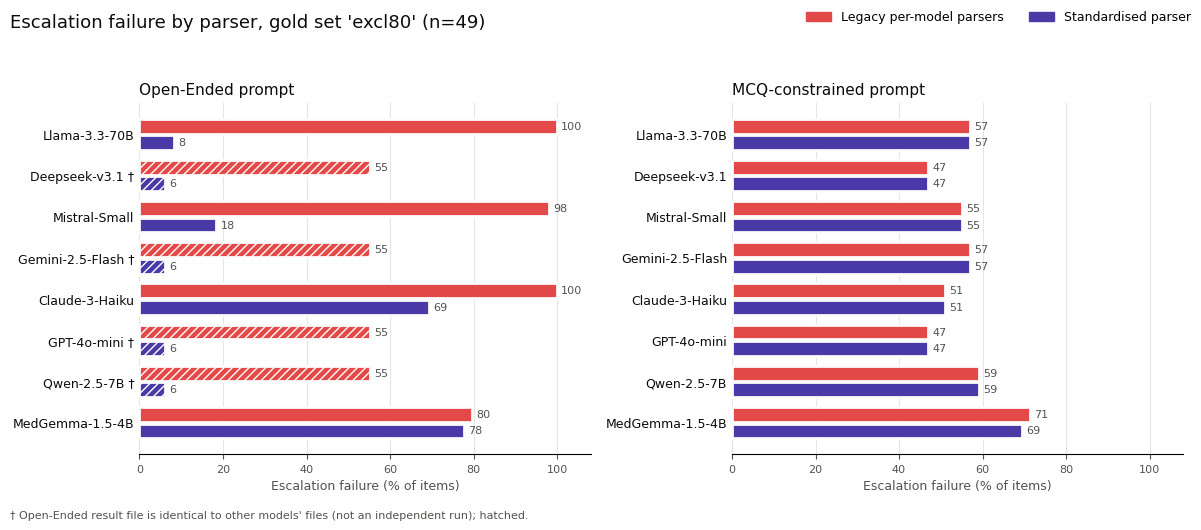

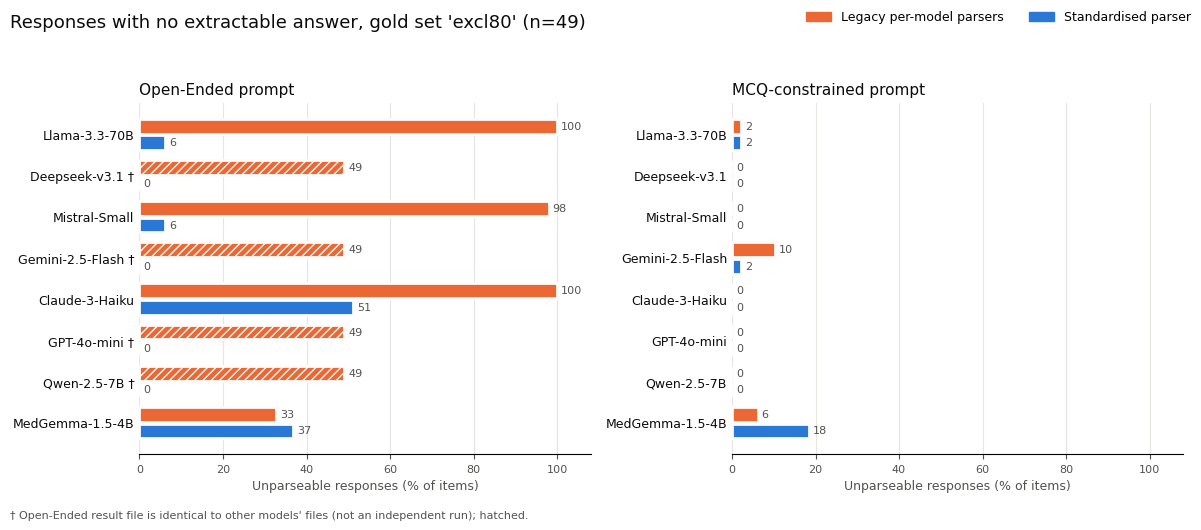

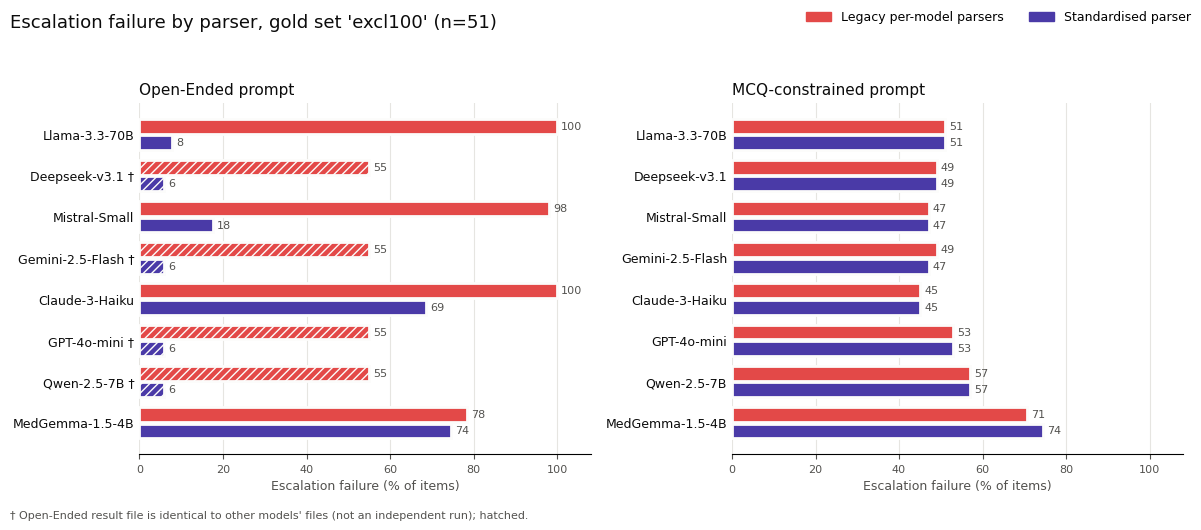

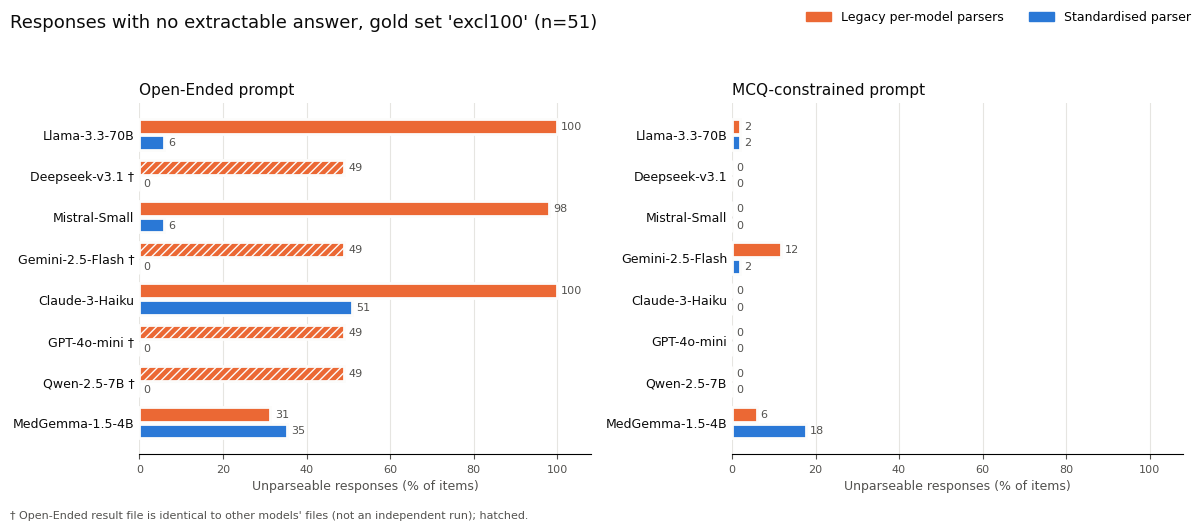

In [7]:
import matplotlib.pyplot as plt

OLD, NEW = "#eb6834", "#2a78d6"                 # unparseable-response charts: orange vs blue
FAIL_OLD, FAIL_NEW = "#e34948", "#4a3aa7"       # escalation-failure charts: red vs violet (both pairs colour-blind-safe, checked)
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"

def compare_bars(df, n, old_col, new_col, xlabel, title, fname, old_colour=OLD, new_colour=NEW):
    """Horizontal grouped bars per model: legacy parser vs standardised parser, one panel per prompt condition."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True)
    for ax, cond in zip(axes, ("OE", "MCQ")):
        d = df[df["cond"].str.startswith(cond)].reset_index(drop=True)
        y = range(len(d))
        for i, row in d.iterrows():
            dup = "DUPLICATE" in row["cond"]
            for off, col, colour in ((-0.2, old_col, old_colour), (0.2, new_col, new_colour)):
                v = row[col] if col.endswith("%") else row[col] / n * 100          # counts -> % of items
                ax.barh(i + off, v, height=0.36, color=colour, edgecolor="#fcfcfb", linewidth=2,
                        hatch="////" if dup else None)
                ax.text(v + 1, i + off, f"{v:.0f}", va="center", fontsize=8, color=MUTED)
        ax.set_yticks(list(y))
        ax.set_yticklabels([m + (" †" if "DUPLICATE" in c else "") for m, c in zip(d["model"], d["cond"])], fontsize=9, color=INK)
        ax.invert_yaxis()
        ax.set_xlim(0, 108); ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
        ax.set_title({"OE": "Open-Ended prompt", "MCQ": "MCQ-constrained prompt"}[cond], fontsize=11, color=INK, loc="left")
        ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
        for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
        ax.tick_params(axis="y", length=0); ax.tick_params(axis="x", colors=MUTED, labelsize=8)
    fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=old_colour), plt.Rectangle((0, 0), 1, 1, color=new_colour)],
               labels=["Legacy per-model parsers", "Standardised parser"], loc="upper right", ncol=2, frameon=False, fontsize=9)
    fig.suptitle(title, x=0.01, ha="left", fontsize=13, color=INK)
    fig.text(0.01, 0.01, "† Open-Ended result file is identical to other models' files (not an independent run); hatched.", fontsize=8, color=MUTED)
    fig.tight_layout(rect=(0, 0.03, 1, 0.94))
    fig.savefig(OUT_DIR / fname, dpi=160, facecolor="#fcfcfb")
    plt.show()

for name in GOLD_SETS:
    f = OUT_DIR / f"rescored_{name}.csv"
    if not f.exists(): continue
    df = pd.read_csv(f); n = int(df["n items"].iloc[0])
    compare_bars(df, n, "Fail legacy %", "Fail (N/A=fail) %", "Escalation failure (% of items)",
                 f"Escalation failure by parser, gold set '{name}' (n={n})", f"fig_failure_{name}.png",
                 old_colour=FAIL_OLD, new_colour=FAIL_NEW)
    compare_bars(df, n, "legacy N/A", "new N/A", "Unparseable responses (% of items)",
                 f"Responses with no extractable answer, gold set '{name}' (n={n})", f"fig_unparseable_{name}.png")